# **Import libraries**

In [ ]:
import tensorflow as tf
import numpy as np
import cv2 as cv
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Creating data**

In [ ]:
train_real = tf.data.Dataset.list_files("/content/drive/MyDrive/face_detection/face_detection_train/face_real/*.jpg",shuffle=False)
train_fake = tf.data.Dataset.list_files("/content/drive/MyDrive/face_detection/face_detection_train/face_fake/*.jpg",shuffle=False)
validation_real = tf.data.Dataset.list_files("/content/drive/MyDrive/face_detection/face_detection_validation/face_real/*.jpg",shuffle=False)
validation_fake = tf.data.Dataset.list_files("/content/drive/MyDrive/face_detection/face_detection_validation/face_fake/*.jpg",shuffle=False)
test_real = tf.data.Dataset.list_files("/content/drive/MyDrive/face_detection/face_detection_test/face_real/*.jpg",shuffle=False)
test_fake = tf.data.Dataset.list_files("/content/drive/MyDrive/face_detection/face_detection_test/face_fake/*.jpg",shuffle=False)


# **Dataset Preprocessing**

In [ ]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    return img

train_real = train_real.map(load_image)
train_fake = train_fake.map(load_image)

validation_real = validation_real.map(load_image)
validation_fake = validation_fake.map(load_image)

test_real = test_real.map(load_image)
test_fake = test_fake.map(load_image)

In [ ]:
def add_label(image, label):
    return image, label

train_real = train_real.map(lambda x: add_label(x, 0))
train_fake = train_fake.map(lambda x: add_label(x, 1))

validation_real = validation_real.map(lambda x: add_label(x, 0))
validation_fake = validation_fake.map(lambda x: add_label(x, 1))

test_real = test_real.map(lambda x: add_label(x, 0))
test_fake = test_fake.map(lambda x: add_label(x, 1))

In [ ]:
train_dataset = train_real.concatenate(train_fake)
validation_dataset = validation_real.concatenate(validation_fake)
test_dataset = test_real.concatenate(test_fake)
train_dataset = train_dataset.shuffle(6400)

In [ ]:
def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_dataset = train_dataset.map(preprocess)

validation_dataset = validation_dataset.map(preprocess)

test_dataset = test_dataset.map(preprocess)

In [ ]:
BATCH_SIZE = 32

train_dataset = train_dataset.batch(BATCH_SIZE)
validation_dataset = validation_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

# **Fine-tuning the model for training**

In [ ]:
model = tf.keras.models.load_model("/content/drive/MyDrive/models/efficientnet_stage3.keras")

base_model = model.layers[1]
base_model.trainable = True

for layer in base_model.layers[:-15]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/efficientnet_finetuned5.keras",
    monitor="val_accuracy",
    save_best_only=True
)

history_finetune = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 1770s 3s/step - accuracy: 0.5723 - loss: 0.6756 - val_accuracy: 0.5656 - val_loss: 0.6802
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.6034 - loss: 0.6637 - val_accuracy: 0.5688 - val_loss: 0.6754
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.6145 - loss: 0.6570 - val_accuracy: 0.5925 - val_loss: 0.6696
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.6345 - loss: 0.6447 - val_accuracy: 0.6000 - val_loss: 0.6657
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.6313 - loss: 0.6421 - val_accuracy: 0.6094 - val_loss: 0.6617
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - accuracy: 0.6575 - loss: 0.6300 - val_accuracy: 0.6194 - val_loss: 0.6574
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.6681 - loss: 0.6246 - val_accuracy: 0.6181 - val_loss: 0.6547
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.6708 - loss: 0.6190 - 

# **Model evaluation**

In [ ]:
model.evaluate(test_dataset)

63/63 ━━━━━━━━━━━━━━━━━━━━ 682s 11s/step - accuracy: 0.6625 - loss: 0.6187


[0.6187254190444946, 0.6625000238418579]

In [ ]:
from pathlib import Path
import json

RESULTS_DIR = Path("/content/drive/MyDrive/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Results directory:", RESULTS_DIR)

Results directory: /content/drive/MyDrive/results


In [ ]:
y_true = []
y_prob = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_prob.extend(predictions.ravel())

y_true = np.asarray(y_true)
y_prob = np.asarray(y_prob)

# Threshold = 0.5
y_pred = (y_prob >= 0.5).astype(int)

print("Number of samples:", len(y_true))

Number of samples: 2000


In [ ]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob
)

roc_auc = auc(fpr, tpr)

metrics = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc)
}

print("\n===== TEST RESULTS =====")

for name, value in metrics.items():
    print(f"{name:<12}: {value:.4f}")


===== TEST RESULTS =====
accuracy    : 0.6625
precision   : 0.6509
recall      : 0.7010
f1_score    : 0.6750
roc_auc     : 0.7216


In [ ]:
metrics_path = RESULTS_DIR / "metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print(f"\nMetrics saved to: {metrics_path}")


Metrics saved to: /content/drive/MyDrive/results/metrics.json


In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=["Real", "Fake"],
    zero_division=0
)

print("\n===== CLASSIFICATION REPORT =====\n")
print(report)
report_path = RESULTS_DIR / "classification_report.txt"

with open(report_path, "w") as f:
    f.write(report)

print(f"Classification report saved to: {report_path}")


===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

        Real       0.68      0.62      0.65      1000
        Fake       0.65      0.70      0.68      1000

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.66      0.66      0.66      2000

Classification report saved to: /content/drive/MyDrive/results/classification_report.txt


In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[624 376]
 [299 701]]


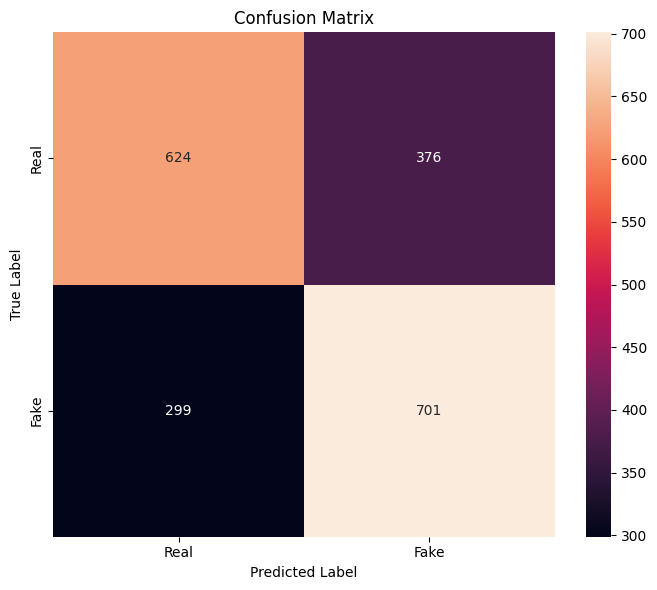

Confusion matrix saved to: /content/drive/MyDrive/results/confusion_matrix.png


In [ ]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()

cm_path = RESULTS_DIR / "confusion_matrix.png"

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"Confusion matrix saved to: {cm_path}")

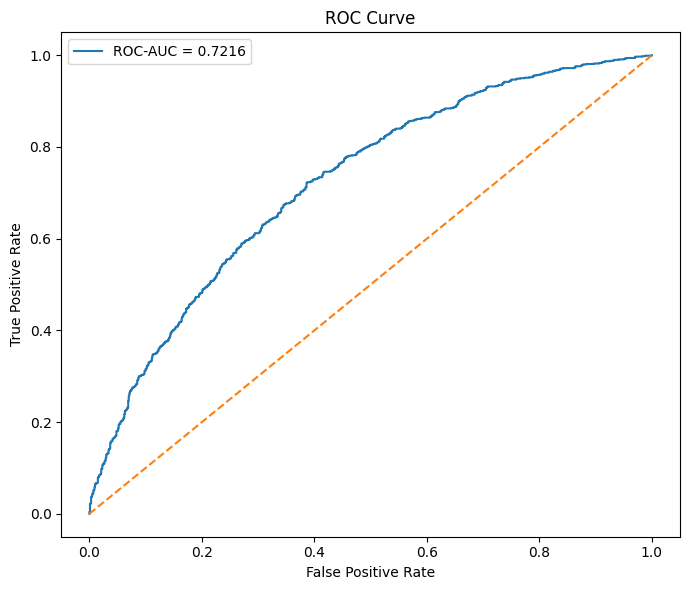

ROC curve saved to: /content/drive/MyDrive/results/roc_curve.png


In [ ]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.tight_layout()

roc_path = RESULTS_DIR / "roc_curve.png"

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"ROC curve saved to: {roc_path}")

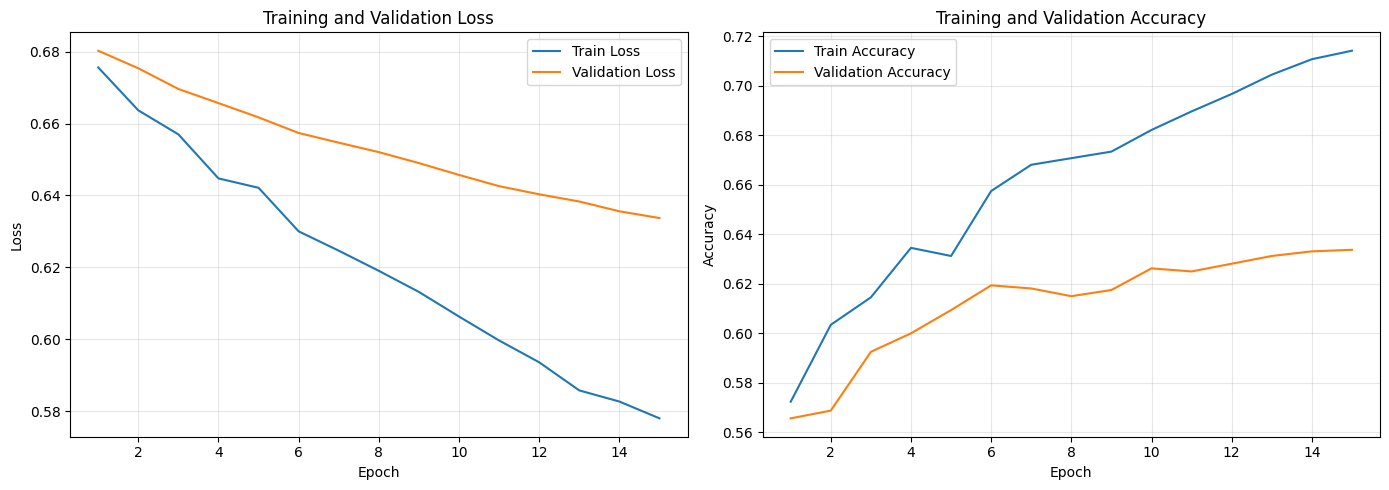

Saved to: /content/drive/MyDrive/results/training_validation_curves.png


In [ ]:

import matplotlib.pyplot as plt

# Get history
train_accuracy = history_finetune.history["accuracy"]
val_accuracy = history_finetune.history["val_accuracy"]

train_loss = history_finetune.history["loss"]
val_loss = history_finetune.history["val_loss"]

epochs = range(1, len(train_accuracy) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.plot(
    epochs,
    train_loss,
    label="Train Loss"
)

plt.plot(
    epochs,
    val_loss,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)

plt.plot(
    epochs,
    train_accuracy,
    label="Train Accuracy"
)

plt.plot(
    epochs,
    val_accuracy,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "training_validation_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(
    f"Saved to: {RESULTS_DIR / 'training_validation_curves.png'}"
)